In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Đọc và downsample
df = pd.read_csv("51.csv", sep=";")
df['time_stamp'] = pd.to_datetime(df['time_stamp'])

df['train_test'].value_counts()
# # ✅ Sử dụng numeric_only=True để bỏ qua cột string
# df_daily = df.set_index('time_stamp').resample('D').mean(numeric_only=True).reset_index()

# # Đọc events
# events = pd.read_csv("../event_info.csv", sep=";")
# events['event_start'] = pd.to_datetime(events['event_start'])
# events['event_end'] = pd.to_datetime(events['event_end'])

# # Plot
# f, ax = plt.subplots(nrows = 2, ncols=1, figsize=(12, 6))
# sns.lineplot(x=df_daily['time_stamp'], y=df_daily['sensor_11_avg'].fillna(np.inf), 
#              ax=ax[0], color='blue', label='Gearbox bearing Temperature (Daily Avg)')

# # Highlight event
# event = events[events['event_id'] == 51].iloc[0]
# ax[0].axvspan(event['event_start'], event['event_end'], 
#            alpha=0.3, color='red', label=f"Anomaly: {event['event_description']}")

# ax[0].set_title('Gearbox bearing - Daily Average')
# ax[0].set_ylabel('Temperature')
# ax[0].set_xlabel('Date')
# ax[0].set_xlim([pd.Timestamp('2023-09-06 01:30:00'), pd.Timestamp('2023-10-25 16:10:00')])
# # Format x-axis to show each day
# import matplotlib.dates as mdates
# ax[0].xaxis.set_major_locator(mdates.DayLocator())
# ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
# plt.setp(ax[0].xaxis.get_majorticklabels(), rotation=45, ha='right')
# ax[0].legend()
# # plt.tight_layout()
# # plt.show()

# df_25 = pd.read_csv("25.csv", sep=';')
# df_25['time_stamp'] = pd.to_datetime(df_25['time_stamp'])
# df_daily = df_25.set_index('time_stamp').resample('D').mean(numeric_only=True).reset_index()

# sns.lineplot(x=df_daily['time_stamp'], y=df_daily['sensor_11_avg'].fillna(np.inf), ax=ax[1],
#             color="orange", label="Gearbox bearing Temperature Normal - Daily Average")

# event = events[events['event_id'] == 25].iloc[0]

# ax[1].axvspan(event['event_start'], event['event_end'], color='red', alpha=0.2,
#             label='Event 25 - Normal')

# ax[1].set_title("Gearbox bearing Temperature Normal - Daily Average")
# ax[1].set_ylabel("Gearbox bearing Temperature Normal")  
# ax[1].set_xlabel("Time")
# ax[1].legend()

# plt.tight_layout()
# plt.show()

train_test
train         52043
prediction     2393
Name: count, dtype: int64

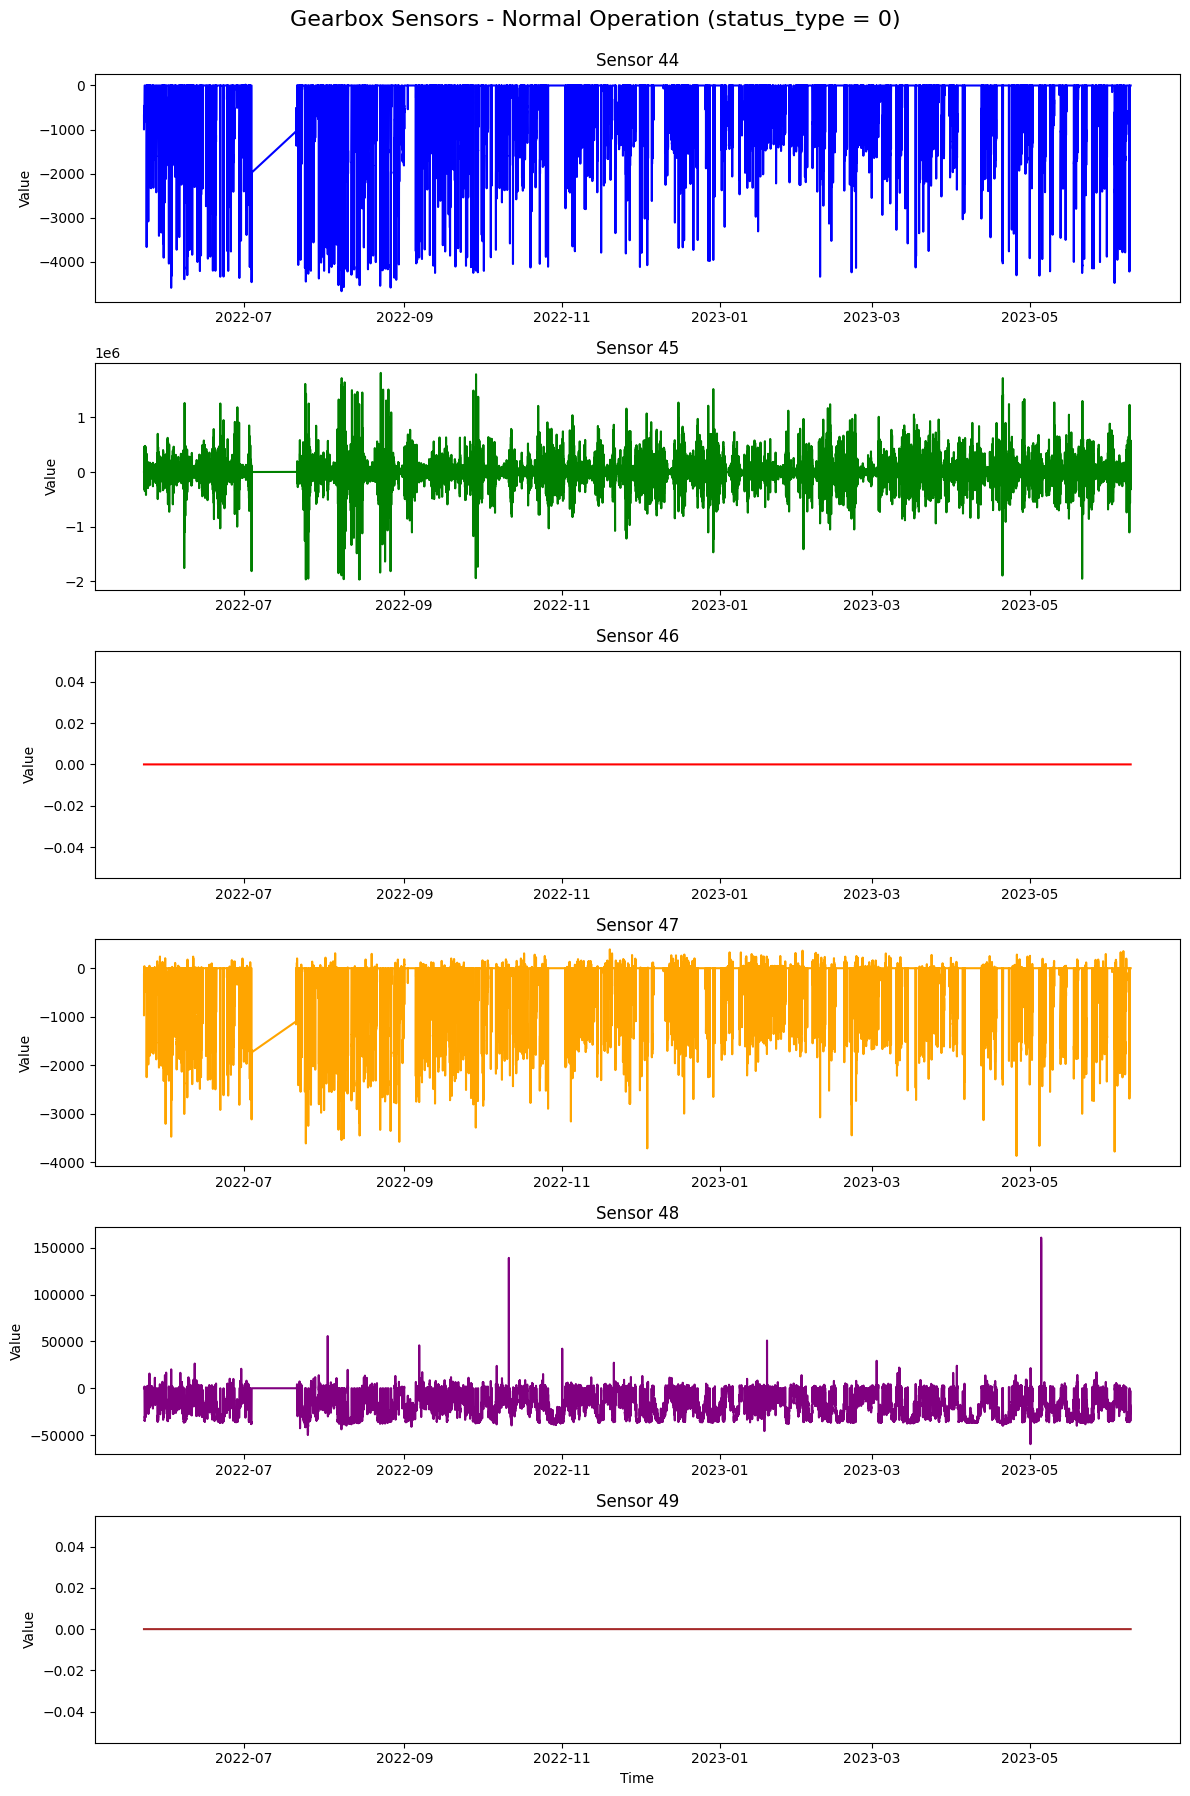

In [2]:
df_service = df_25[df_25['status_type_id'] == 0][['time_stamp', 'sensor_44', 'sensor_45', 'sensor_46', 'sensor_47', 'sensor_48', 'sensor_49']]

# Create subplots - 6 rows, 1 column
f, axes = plt.subplots(nrows=6, ncols=1, figsize=(12, 18))

# Sensor 44
sns.lineplot(data=df_service, x='time_stamp', y='sensor_44', ax=axes[0], color='blue')
axes[0].set_title('Sensor 44')
axes[0].set_ylabel('Value')
axes[0].set_xlabel('')

# Sensor 45
dt_hours = 10/60
df_service['P_delta_kW'] = df_service['sensor_45'].diff() / dt_hours
sns.lineplot(data=df_service, x='time_stamp', y='P_delta_kW', ax=axes[1], color='green')
axes[1].set_title('Sensor 45')
axes[1].set_ylabel('Value')
axes[1].set_xlabel('')

# Sensor 46
sns.lineplot(data=df_service, x='time_stamp', y='sensor_46', ax=axes[2], color='red')
axes[2].set_title('Sensor 46')
axes[2].set_ylabel('Value')
axes[2].set_xlabel('')

# Sensor 47
sns.lineplot(data=df_service, x='time_stamp', y='sensor_47', ax=axes[3], color='orange')
axes[3].set_title('Sensor 47')
axes[3].set_ylabel('Value')
axes[3].set_xlabel('')

# Sensor 48
sns.lineplot(data=df_service, x='time_stamp', y='sensor_48', ax=axes[4], color='purple')
axes[4].set_title('Sensor 48')
axes[4].set_ylabel('Value')
axes[4].set_xlabel('')

# Sensor 49
sns.lineplot(data=df_service, x='time_stamp', y='sensor_49', ax=axes[5], color='brown')
axes[5].set_title('Sensor 49')
axes[5].set_ylabel('Value')
axes[5].set_xlabel('Time')

# Add overall title
f.suptitle('Gearbox Sensors - Normal Operation (status_type = 0)', fontsize=16, y=0.995)

plt.tight_layout()
plt.show()

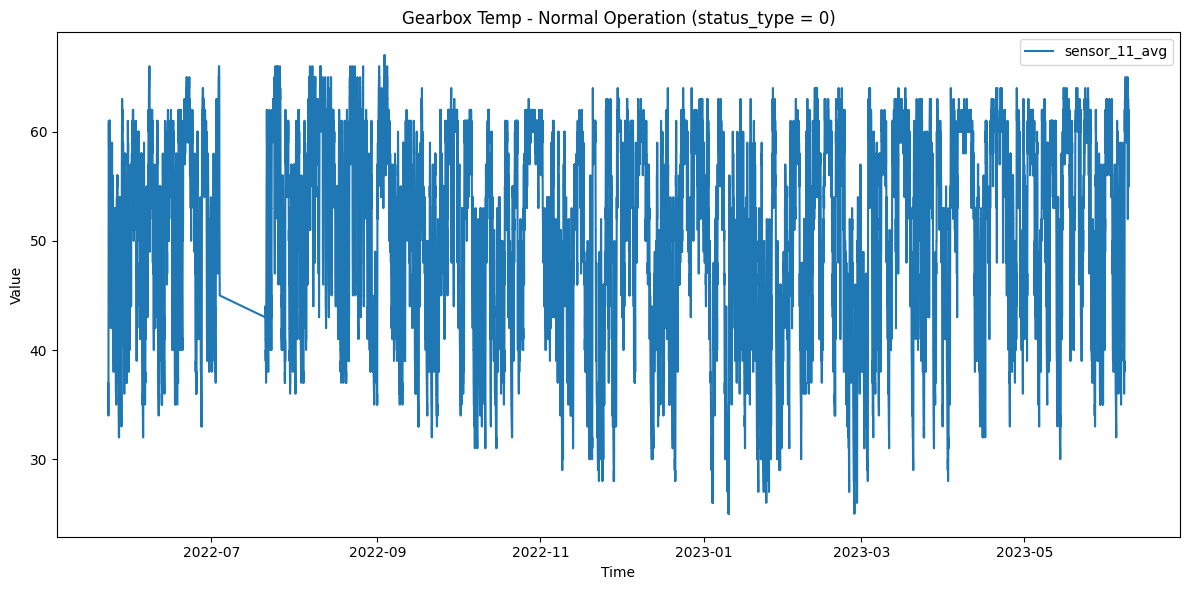

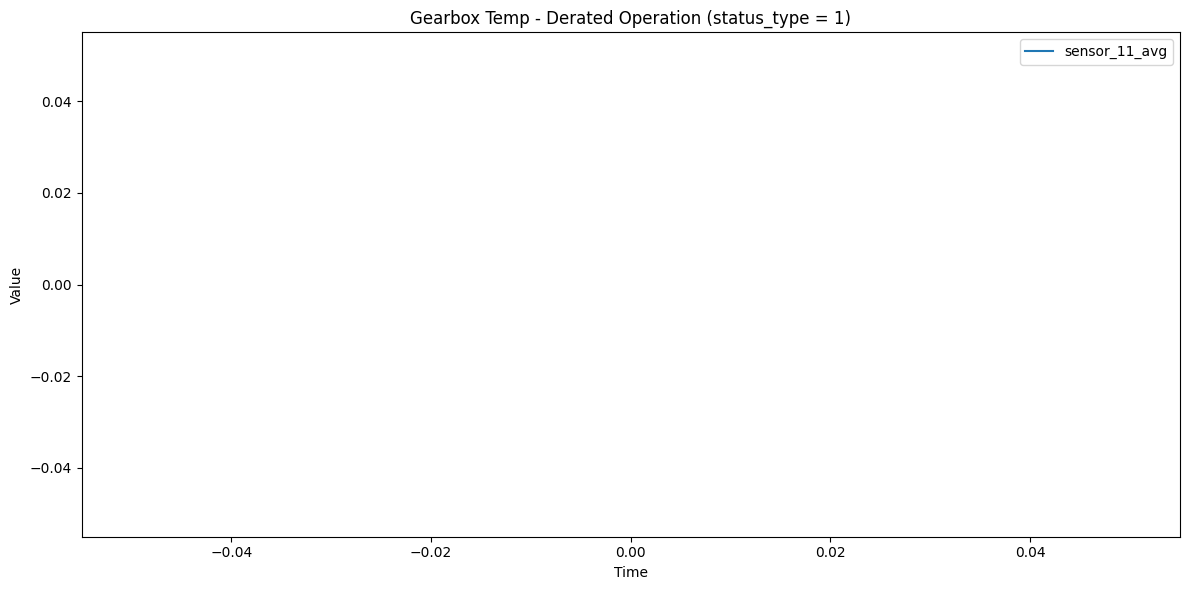

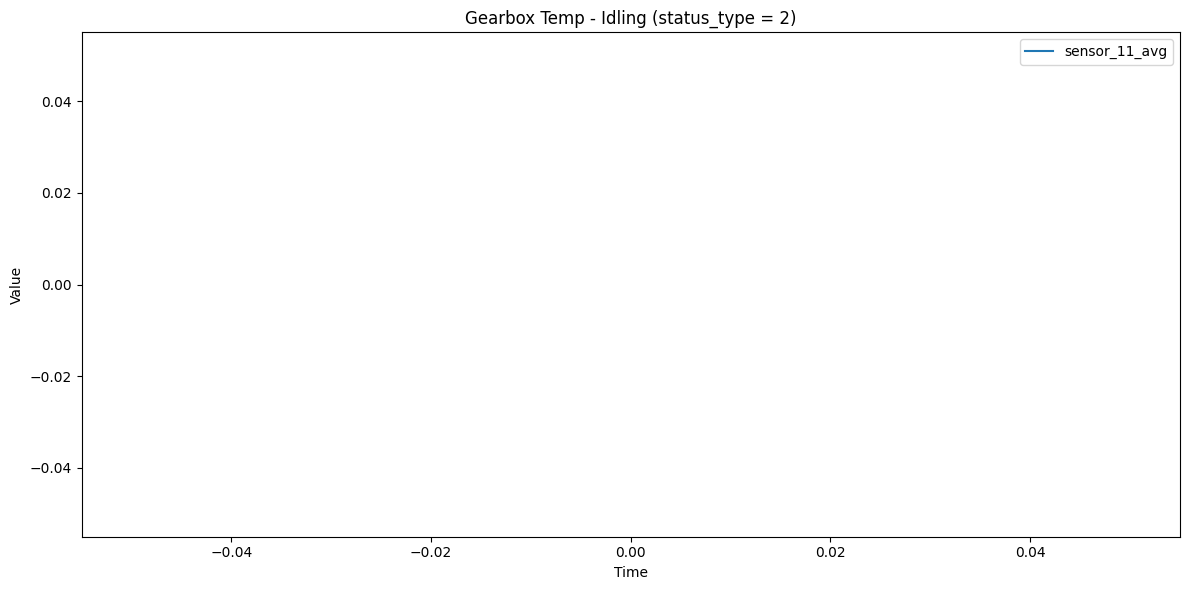

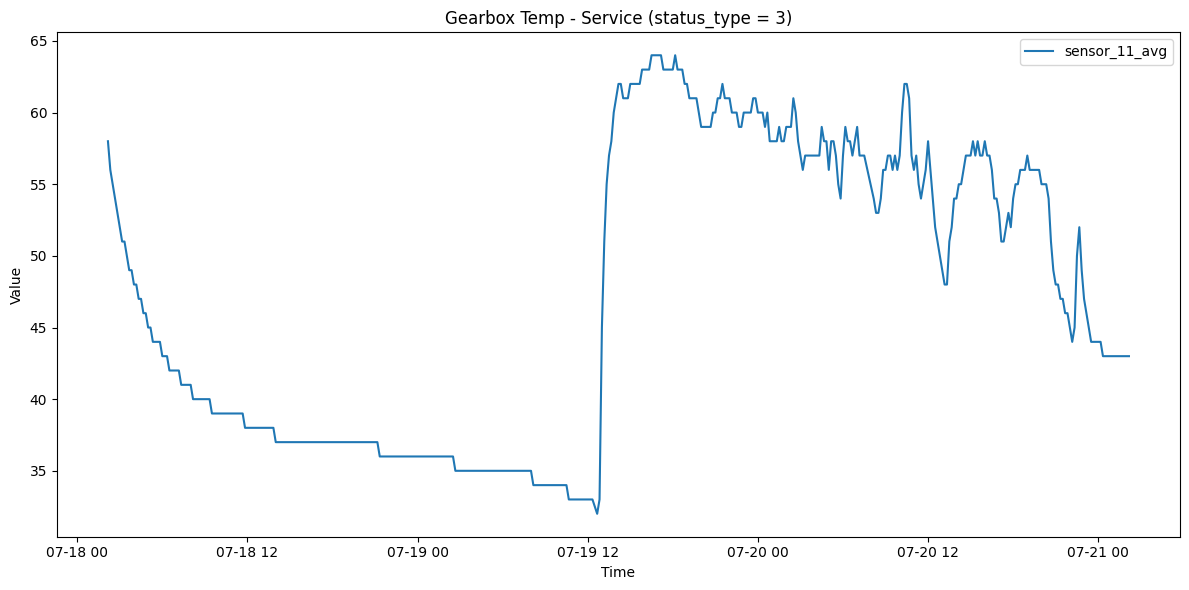

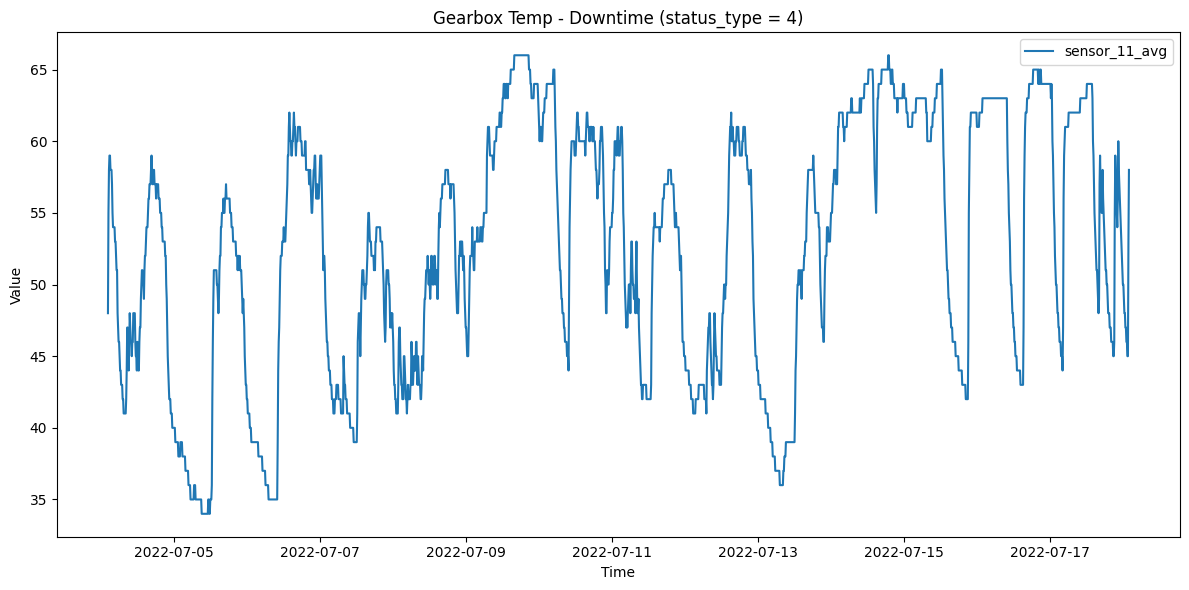

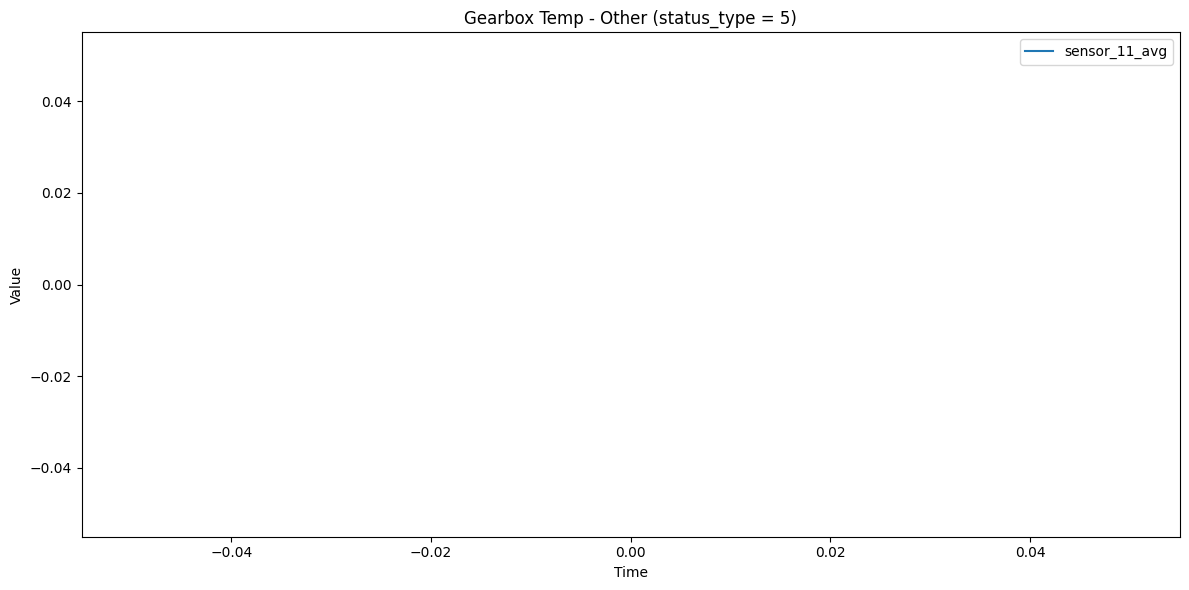

In [3]:
status_type_names = {
    0: "Normal Operation",
    1: "Derated Operation",
    2: "Idling",
    3: "Service",
    4: "Downtime",
    5: "Other"
}

for i in range(6):
    type_name = status_type_names[i]
    df_service = df_25[df_25['status_type_id'] == i][['time_stamp', 'sensor_11_avg']]

    # Plot all on one axis
    f, ax = plt.subplots(figsize=(12, 6))

    sns.lineplot(data=df_service, x='time_stamp', y='sensor_11_avg', ax=ax, label='sensor_11_avg')
    # sns.lineplot(data=df_service, x='time_stamp', y='sensor_45', ax=ax, label='Sensor 45')
    # sns.lineplot(data=df_service, x='time_stamp', y='sensor_46', ax=ax, label='Sensor 46')
    ax.set_title(f'Gearbox Temp - {type_name} (status_type = {i})')
    ax.set_ylabel('Value')
    ax.set_xlabel('Time')
    ax.legend()

    plt.tight_layout()
    plt.show()

In [4]:
#CHECK STATUS TYPE IN A DATASET
# Get counts
status_counts = df_25['status_type_id'].value_counts().sort_index()

print("Status Type Distribution:")
print("=" * 70)
for status_type, count in status_counts.items():
    meaning = status_type_names.get(status_type, "Unknown")
    percentage = (count / len(df_25)) * 100
    print(f"Type {status_type} ({meaning:20s}): {count:8,} rows ({percentage:6.2f}%)")
print("=" * 70)
print(f"Total: {len(df_25):,} rows")

Status Type Distribution:
Type 0 (Normal Operation    ):   52,267 rows ( 95.53%)
Type 3 (Service             ):      429 rows (  0.78%)
Type 4 (Downtime            ):    2,016 rows (  3.68%)
Total: 54,712 rows


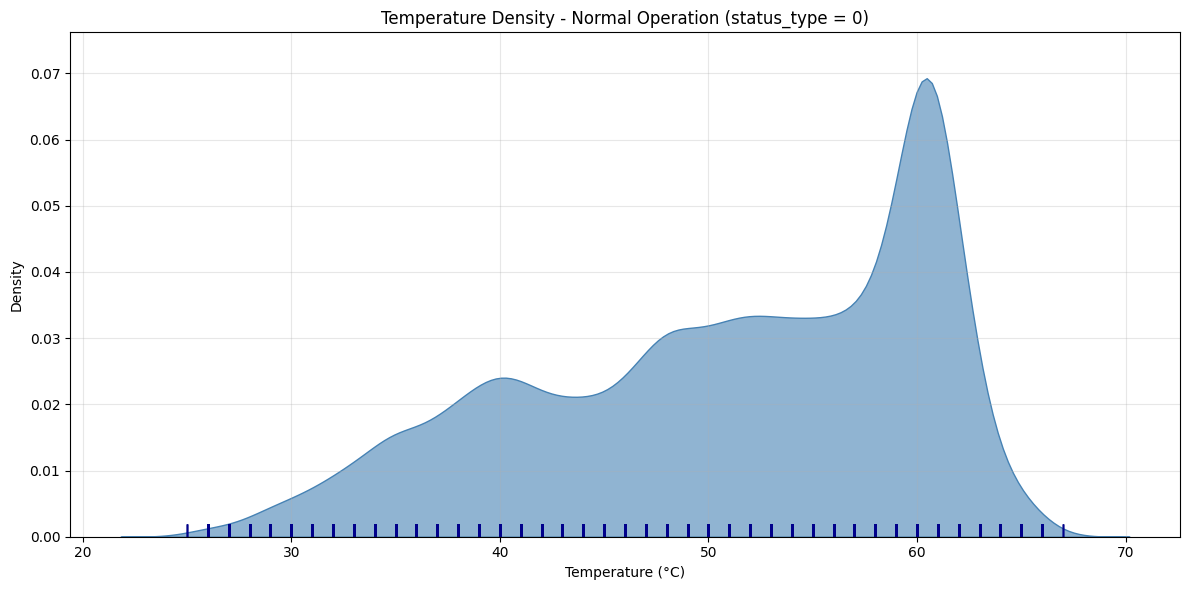

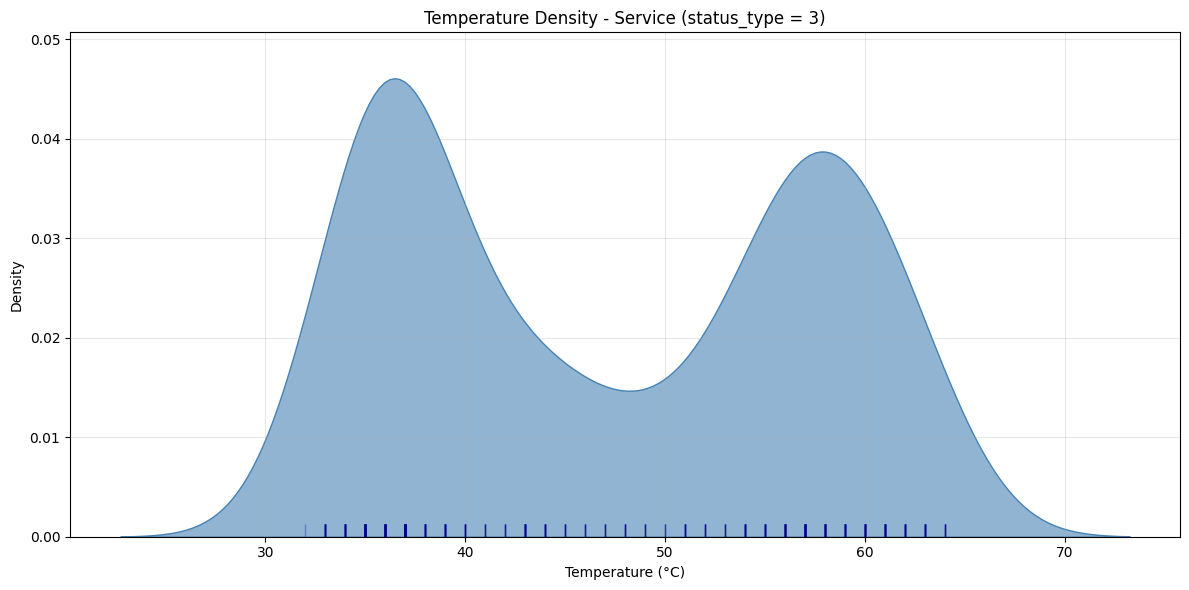

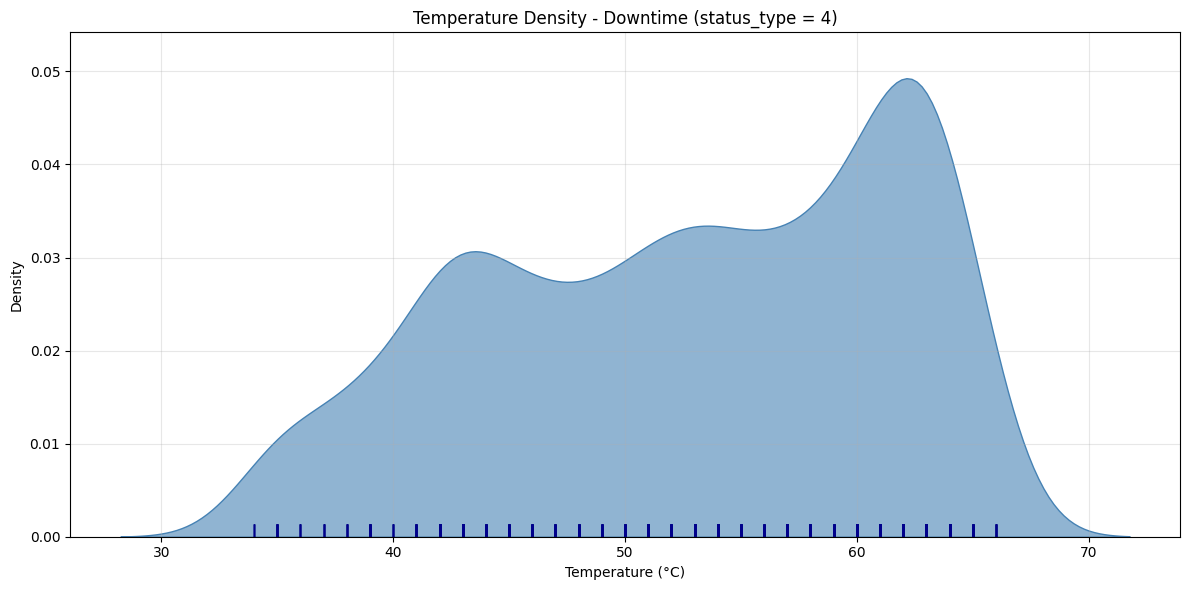

In [5]:
for i in range(6):
    type_name = status_type_names[i]
    df_service = df_25[df_25['status_type_id'] == i][['time_stamp', 'sensor_11_avg']].dropna()
    
    if len(df_service) == 0:
        continue
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # KDE plot shows where temperatures are most dense
    sns.kdeplot(data=df_service, x='sensor_11_avg', fill=True, ax=ax, color='steelblue', alpha=0.6)
    
    # Add rug plot to show individual data points
    sns.rugplot(data=df_service, x='sensor_11_avg', ax=ax, color='darkblue', alpha=0.3)
    
    ax.set_title(f'Temperature Density - {type_name} (status_type = {i})')
    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel('Density')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

<Axes: >

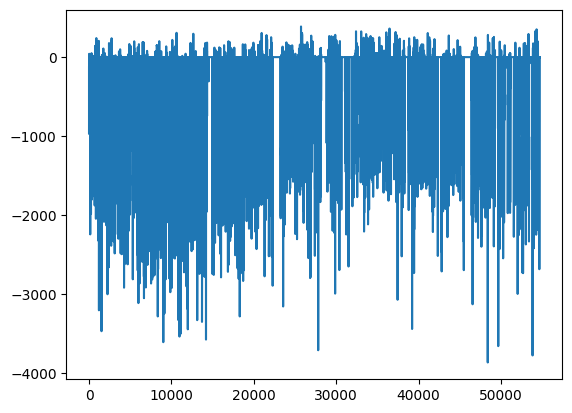

In [6]:
df_25['sensor_47'].plot()


In [ ]:
df_25 = df_25[df_25['status_type_id'] == 0]
df_25.set_index('time_stamp', inplace=True)
tabel = perspective.tabel(df_25, index="index")

SyntaxError: invalid syntax (3623891307.py, line 1)